# Panel Data Example

In this example, we will use [California Smoke Data](https://www.tandfonline.com/doi/abs/10.1198/jasa.2009.ap08746) [1] to show the usage of [CausalTensor](https://github.com/TianyiPeng/causaltensor) package.

[1] Abadie, Alberto, Alexis Diamond, and Jens Hainmueller. "Synthetic control methods for comparative case studies: Estimating the effect of California’s tobacco control program." Journal of the American statistical Association 105, no. 490 (2010): 493-505.

In [1]:
import numpy as np


Install and import `causaltensor` package

In [2]:
import numpy as np
from pathlib import Path
import subprocess
import sys


def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "src" / "causaltensor" / "cauest" / "MCNNM.py").exists():
            return candidate
    return None


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if PROJECT_ROOT is not None:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
    for module_name in list(sys.modules):
        if module_name == "causaltensor" or module_name.startswith("causaltensor."):
            del sys.modules[module_name]
    TUTORIALS_DIR = PROJECT_ROOT / "tutorials"
else:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "causaltensor"])
    TUTORIALS_DIR = Path.cwd()

import causaltensor as ct


## Load Data

*California Smoke Data* consists of annual tobacco consumption (smoking consumption in packs per capita) of 39 states from 1970 to 2000.

Among those states, California (the treated state) started a state-level tobacco control program in 1989; while other states largely serve as control states. The problem at hand is to evaluate the impact of this program to the tobacco consumption in California given the data.

Let's first download the data.

In [3]:
from pathlib import Path
import urllib.request
import zipfile

DATA_DIR = TUTORIALS_DIR if (TUTORIALS_DIR / "MLAB_data.txt").exists() else Path.cwd()

if not (DATA_DIR / "MLAB_data.txt").exists():
    zip_path = Path.cwd() / "Synth.zip"
    urllib.request.urlretrieve(
        "https://github.com/TianyiPeng/causaltensor/raw/main/tutorials/Synth.zip",
        zip_path,
    )
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(Path.cwd())
    DATA_DIR = Path.cwd()

print(f"Using tutorial data from {DATA_DIR}")


Using tutorial data from /Users/federicomolina/Documents/github/causaltensor/tutorials


Load and pre-process the outcome data

In [4]:
O_raw = np.loadtxt(DATA_DIR / "MLAB_data.txt")
O = O_raw[8:, :] ## remove features that are not relevant in this demo
O = O.T
print(O.shape)
## now O consists of the annual tobacco consumption of 39 states from 1970 to 2000
## California is the last row of O


(39, 31)


Let's take a look for the California data

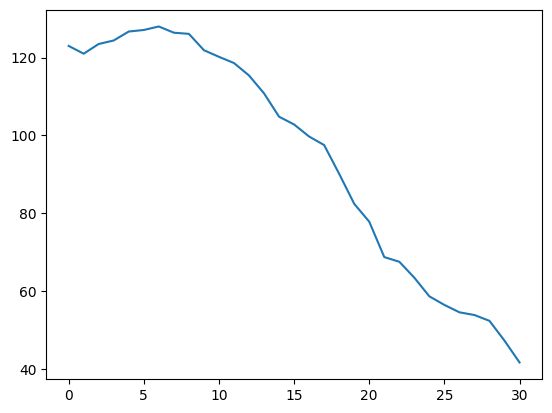

In [5]:
import matplotlib.pyplot as plt

plt.plot(O[-1, :])

Prepare intervention matrix $Z$ that indicates whether the intervention is implemented or not

In [6]:
Z = np.zeros_like(O) # Z has the same shape as O
Z[-1, 19:] = 1 #Only California (the last row) used the intervention, which started in 1989

## Estimators

Now after we have the outcome data ($O \in R^{n\times T}$) and the intervention data ($Z \in R^{n\times T}$), let's show a few methods that can be used directly to assess the impact of the intervention.

## DID estimation

The first method is difference-in-difference (DID). We use a two-way fixed effects regression to estimate the average treatment effect on the treated entries (ATT). In particular, we solve the following regression by linear regression
$$
\min \sum_{ij} (O_{ij} - a_i - b_j - \tau Z_{ij})^2
$$
where $a_{i}, b_{j}$ are unknown fixed effects and $\tau$ is the ATT.

To use DID, simply call
```
M, tau = DID(O, Z)
````
with two return parameters `M` and `tau`. Here $M_{ij}=a_{i}+b_{j}$ is the estimated ideal outcomes; and `tau` is the estimated ATT.

In [7]:
from causaltensor.cauest import DID

M, tau = DID(O, Z)
print('The estimation of DID is', tau)

The estimation of DID is -27.349111083614957


## Debiased Convex Panel Regression

The second method is De-biaeed Convex Panel Regression (DC-PR) proposed by [2].
Note that an issue of the DID model is that, $a_i+b_j$ are often too simple to describe the complex reality of the outcome. As a fix, a low-rank factor model to generalize $a_i+b_j$ has been advocated.

The idea in [2] is to firstly solve the following low-rank regression problem by replacing $a_i+b_j$ in DID by a low-rank matrix $M$
$$
\hat{M}, \hat{\tau} = \arg\min \sum_{ij} (O_{ij}-M_{ij}-\tau Z_{ij})^2 + \lambda \|M\|_{*}
$$
where $\|M\|_{*}$ is the nuclear norm to penalize the low-rankness of the matrix and $\lambda$ is a tunning parameter. The second step of [2] is to mitigate the bias induced by the regularization parameter (it also reflects the interaction between $\hat{M}$ and $Z$):
$$
\tau^{d} = \hat{\tau} - \lambda \frac{<Z, \hat{U}\hat{V}^{\top}>}{\|P_{\hat{T}^{\perp}}(Z)\|_{F}^2}.
$$
See [2] for more details.

To use DC-PR, call
```
M, tau, std = DC_PR_auto_rank(O, Z)
```
where `M`, `tau` are the final estimators for the low-rank matrix and the treatment effects respectively. In addition `std` is the stanard deviation estimation for `tau`, using the formula in [2] for the scenarios when noises are (heterogenoues) independent sub-Gaussian. This function helps to find the proper rank for $M$ (but not very stable, and may be updated later). You can also use
```
M, tau, std = DC_PR_with_suggested_rank(O, Z, suggest_r = r)
```
if you have an estimation of the rank of $M$ by yourself.

[2] Farias, Vivek, Andrew Li, and Tianyi Peng. "Learning treatment effects in panels with general intervention patterns." Advances in Neural Information Processing Systems 34 (2021): 14001-14013.

In [8]:
from causaltensor.cauest import DC_PR_with_suggested_rank
from causaltensor.cauest import DC_PR_auto_rank

#M, tau, std = DebiasConvex.DC_PR_with_suggested_rank(O, Z, suggest_r = 2)
M, tau, std = DC_PR_auto_rank(O, Z)
print('The estimation of DC_PR is', tau, std)

The estimation of DC_PR is -16.010577370658964 3.0130206385406946


We also implemented the panel regression with a hard rank constraint:
$$
\hat{M}, \hat{\tau} = \arg\min_{rank(M)\leq r} \sum_{ij} (O_{ij}-M_{ij}-\tau Z_{ij})^2
$$
This is a non-convex optimization problem and we used the alternate minimization between $M$ and $\tau$ for the optimization. The theoretical guarantee for this non-convex method is weaker than the convex method above (the convergence to the global optimum is not always guaranteed), but the practical performance is comparable (sometimes even better).  

In [9]:
M, tau, std = DC_PR_with_suggested_rank(O, Z, suggest_r = 2, method='non-convex')
print(tau, std)

-15.880704119035295 3.0118139242894277


We also provide an option to select `convex` or `non-convex` panel regression in a data-driven fasion. This is recommended in practice.

In [10]:
M, tau, std = DC_PR_with_suggested_rank(O, Z, suggest_r = 2, method='auto')
print(tau, std)

-15.880704119035295 3.0118139242894277


## SDID estimation

The second method is called synthetic difference-in-difference (SDID) proposed by [3]. Readers can read [3] for more details. To use SDID, simply call
```
tau = SDID(O, Z)
```
where `tau` is the estimation of SDID.

[3] Arkhangelsky, Dmitry, Susan Athey, David A. Hirshberg, Guido W. Imbens, and Stefan Wager. "Synthetic difference-in-differences." American Economic Review 111, no. 12 (2021): 4088-4118.

In [11]:
from causaltensor.cauest import SDID

## to use SDID, cvxopt package is needed

tau = SDID(O, Z)
print('The estimation of SDID is', tau) ## The result matched the result in [2]

The estimation of SDID is -15.61431090150178


p = 1, SDID tau = -16.539671285922704
p = 2, SDID tau = -12.402794465067027
p = 3, SDID tau = -18.730933502033807
p = 4, SDID tau = -12.19259129934589
p = 5, SDID tau = -18.659521007643455
p = 6, SDID tau = -13.96672610975754
p = 7, SDID tau = -16.15125042007348
p = 8, SDID tau = -10.73480065388118
p = 9, SDID tau = -23.312094394723342
p = 10, SDID tau = -13.748113451308004
p = 11, SDID tau = -12.636696492107852
p = 12, SDID tau = -19.236770262379945
p = 13, SDID tau = -19.413859360829665
p = 14, SDID tau = -8.270521827469773
p = 15, SDID tau = -16.276325476709246
p = 16, SDID tau = -10.806997302864314
p = 17, SDID tau = -2.056041270362535
p = 18, SDID tau = -15.886851581450706
p = 19, SDID tau = 2.852840617999361


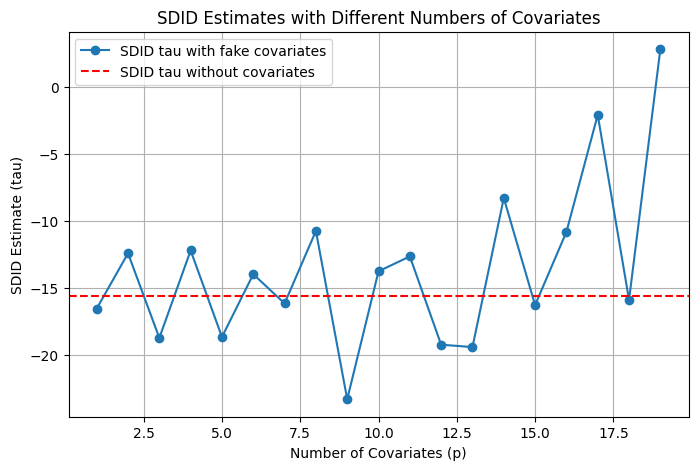

In [12]:
# Here we generate synthetic time-varying exogenous covariates X_cov.
# We want X_cov to have shape (n, T, p), where:
#   n: number of units (rows in O)
#   T: number of time periods (columns in O)
#   p: number of covariates (here we try various p to see 'stability')
np.random.seed(0)

p_values = range(1, 20)
tau_estimates = []

n, T = O.shape

tau_no_cov = SDID(O, Z)

for p in p_values:
    X_cov = np.random.randn(n, T, p)
    tau = SDID(O, Z, X_cov=X_cov)
    tau_estimates.append(tau)
    print(f"p = {p}, SDID tau = {tau}")

plt.figure(figsize=(8, 5))
plt.plot(p_values, tau_estimates, marker='o', label='SDID tau with fake covariates')
plt.axhline(tau_no_cov, color='red', linestyle='--', label='SDID tau without covariates')
plt.xlabel("Number of Covariates (p)")
plt.ylabel("SDID Estimate (tau)")
plt.title("SDID Estimates with Different Numbers of Covariates")
plt.legend()
plt.grid(True)
plt.show()

## Matrix Completion

The third method is based on matrix completion method proposed by [4]. The idea is to solve the following matrix completion problem, only using the outcome data without intervention (i.e., $Z_{ij}=0$)
$$
\hat{M}, \hat{a}, \hat{b} = \arg\min \sum_{ij, Z_{ij}=0} (O_{ij}-M_{ij} - a_i - b_j)^2 + \lambda \|M\|_{*}
$$
where $\|M\|_{*}$ is the nuclear norm that penalizes the low-rankness of the matrix (here $a_{i}$ and $b_{j}$ are used to improve the empirical performance, as suggested by [4]).

After $\hat{M}, \hat{a}, \hat{b}$ are obtained, the ATT $\hat{\tau}$ can be estimated simply by
$$
\hat{\tau} = \frac{\sum_{ij, Z_{ij}=1} (O_{ij} - \hat{M}_{ij} - \hat{a}_i - \hat{b}_{j})}{\sum_{ij, Z_{ij}=1} 1}.
$$

The recommended MC-NNM API is now `MCNNMPanelSolver.fit`. It chooses the solving method from the arguments you pass:

```python
solver = MCNNMPanelSolver(Z=Z)
result = solver.fit(O=O, suggest_r=r)      # suggested rank
result = solver.fit(O=O, l=2.0)            # fixed nuclear-norm regularizer
result = solver.fit(O=O, K=5, list_l=None) # cross-validation over regularizers
```

The old functional API is still available for backward compatibility:

```python
M, a, b, tau = MC_NNM_with_suggested_rank(O, 1-Z, suggest_r=r)
M, a, b, tau = MC_NNM_with_cross_validation(O, 1-Z)
```

[4] Athey, Susan, Mohsen Bayati, Nikolay Doudchenko, Guido Imbens, and Khashayar Khosravi. "Matrix completion methods for causal panel data models." Journal of the American Statistical Association 116, no. 536 (2021): 1716-1730.


In [13]:
from causaltensor.cauest import MCNNMPanelSolver

solver = MCNNMPanelSolver(Z=Z)
result = solver.fit(O=O, suggest_r=1)
M, a, b, tau = result.M, result.row_fixed_effects, result.column_fixed_effects, result.tau

# Old API equivalent:
# from causaltensor.cauest import MC_NNM_with_suggested_rank
# M, a, b, tau = MC_NNM_with_suggested_rank(O, 1-Z, suggest_r=1)

tau


-22.34540156911949

In [14]:
result = solver.fit(O=O, K=5)
M, a, b, tau = result.M, result.row_fixed_effects, result.column_fixed_effects, result.tau

# Old API equivalent:
# from causaltensor.cauest import MC_NNM_with_cross_validation
# M, a, b, tau = MC_NNM_with_cross_validation(O, 1-Z, K=5)

print('The estimation of MC_NNM is', tau)


The estimation of MC_NNM is -20.267535327741044
